# Lecture 10 · Dice vs Cross-Entropy on toy masks

**Goal** · on a tiny segmentation mask with heavy foreground/background imbalance, compare pixelwise cross-entropy and soft-Dice loss — and see why Dice is preferred when the object is small.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1 · An imbalanced ground-truth mask

A $32\times32$ image with a small $4\times4$ foreground object: only ~1.6% of pixels are foreground.

In [2]:
H = W = 32
g = np.zeros((H, W))
g[14:18, 14:18] = 1.0        # small foreground square
frac = g.mean()
print(f'foreground pixels: {int(g.sum())} / {H*W}  ({frac*100:.1f}%)  -> severe imbalance')

foreground pixels: 16 / 1024  (1.6%)  -> severe imbalance


## 2 · The two losses

Pixelwise binary cross-entropy and **soft-Dice**:

$$L_{Dice}=1-\frac{2\sum_i p_i g_i+\epsilon}{\sum_i p_i+\sum_i g_i+\epsilon}.$$

In [3]:
def bce(p, g, eps=1e-7):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(g * np.log(p) + (1 - g) * np.log(1 - p))

def dice_loss(p, g, eps=1e-6):
    num = 2 * np.sum(p * g) + eps
    den = np.sum(p) + np.sum(g) + eps
    return 1 - num / den

## 3 · The trap: predicting *all background*

A lazy predictor that outputs ~0 everywhere is right on 98% of pixels, so CE looks *low* — but it misses the object entirely, which Dice punishes hard.

In [4]:
p_allbg = np.full((H, W), 0.01)             # 'everything is background'
p_good  = np.where(g == 1, 0.99, 0.01)      # correct mask

print(f'{"predictor":<16}{"BCE":>8}{"Dice loss":>12}')
for name, p in [('all-background', p_allbg), ('good mask', p_good)]:
    print(f'{name:<16}{bce(p, g):>8.3f}{dice_loss(p, g):>12.3f}')

predictor            BCE   Dice loss
all-background     0.082       0.988
good mask          0.010       0.244


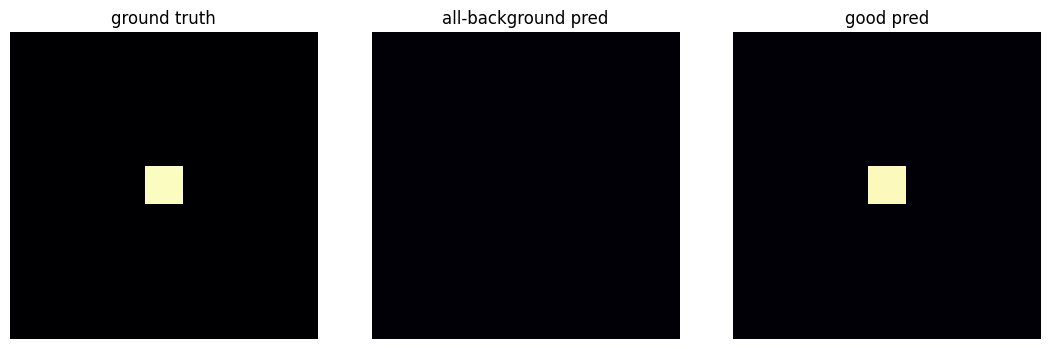

BCE calls the all-background predictor "good" (low loss);
Dice sees ~0 overlap with the object and returns ~1.0 (bad). Dice resists imbalance.


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
for a, (t, im) in zip(ax, [('ground truth', g), ('all-background pred', p_allbg), ('good pred', p_good)]):
    a.imshow(im, cmap='magma', vmin=0, vmax=1); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

print('BCE calls the all-background predictor "good" (low loss);')
print('Dice sees ~0 overlap with the object and returns ~1.0 (bad). Dice resists imbalance.')

## Takeaway

- With a tiny object, pixel CE is dominated by easy background — a trivial all-background predictor scores well.
- Soft-Dice measures *overlap* with the foreground, so it stays high (bad) until the object is found.
- For imbalanced segmentation, combine CE with Dice (or use Dice/IoU losses).